In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import os
os.makedirs("../artifacts", exist_ok=True)

sys.path.append("..")
from components.data_ingestion import DataLoader

loader = DataLoader("data.csv")
df = loader.load()


Resort_hotel = df[df['hotel'] == 'Resort Hotel']
Resort_hotel.to_csv("../artifacts/Resort_hotel.csv", index=False)

City_hotel = df[df['hotel'] == 'City Hotel']
City_hotel.to_csv("../artifacts/City_hotel.csv", index=False)




In [ ]:
# Exploratory Data Analysis

print("Top 5", Resort_hotel.head(5))
print("\nSummary Stats", Resort_hotel.describe())
print("\nMissing values",Resort_hotel.isnull().sum())
print("\ncolumns",Resort_hotel.columns)
print("\nData Types",Resort_hotel.dtypes)
print("\nShape",Resort_hotel.shape)

In [3]:
# Remove Undefined from Resort data
Resort_hotel = Resort_hotel[Resort_hotel['distribution_channel'] != 'Undefined']
Resort_hotel

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,distribution_channel,reserved_room_type,assigned_room_type,booking_changes,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Direct,C,C,3,0,Transient,0.00,0,0,7/1/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Direct,C,C,4,0,Transient,0.00,0,0,7/1/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Direct,A,C,0,0,Transient,75.00,0,0,7/2/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Corporate,A,A,0,0,Transient,75.00,0,0,7/2/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,TA/TO,A,A,0,0,Transient,98.00,0,1,7/3/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40055,Resort Hotel,0,212,2017,August,35,31,2,8,2,...,TA/TO,A,A,1,0,Transient,89.75,0,0,9/10/2017
40056,Resort Hotel,0,169,2017,August,35,30,2,9,2,...,Direct,E,E,0,0,Transient-Party,202.27,0,1,9/10/2017
40057,Resort Hotel,0,204,2017,August,35,29,4,10,2,...,Direct,E,E,0,0,Transient,153.57,0,3,9/12/2017
40058,Resort Hotel,0,211,2017,August,35,31,4,10,2,...,TA/TO,D,D,0,0,Contract,112.80,0,1,9/14/2017


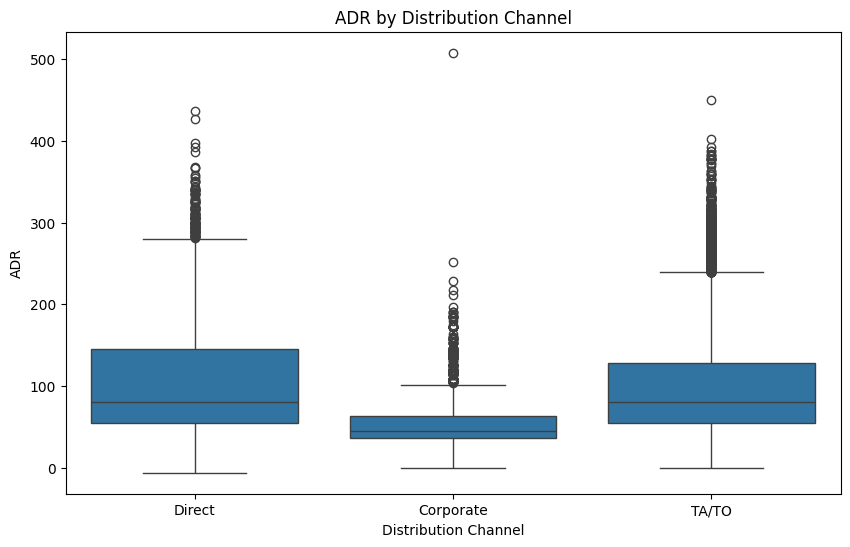

In [ ]:
# Boxplot for ADR by Distribution Channel
plt.figure(figsize=(10, 6))
sns.boxplot(x='distribution_channel', y='adr', data=Resort_hotel)
plt.title('ADR by Distribution Channel')
plt.xlabel('Distribution Channel')
plt.ylabel('ADR')
plt.show()

In [5]:
# Remove Room type P as it has 0 revenue.

Resort_hotel = Resort_hotel[Resort_hotel['reserved_room_type'] != 'P']
Resort_hotel

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,distribution_channel,reserved_room_type,assigned_room_type,booking_changes,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Direct,C,C,3,0,Transient,0.00,0,0,7/1/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Direct,C,C,4,0,Transient,0.00,0,0,7/1/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Direct,A,C,0,0,Transient,75.00,0,0,7/2/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Corporate,A,A,0,0,Transient,75.00,0,0,7/2/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,TA/TO,A,A,0,0,Transient,98.00,0,1,7/3/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40055,Resort Hotel,0,212,2017,August,35,31,2,8,2,...,TA/TO,A,A,1,0,Transient,89.75,0,0,9/10/2017
40056,Resort Hotel,0,169,2017,August,35,30,2,9,2,...,Direct,E,E,0,0,Transient-Party,202.27,0,1,9/10/2017
40057,Resort Hotel,0,204,2017,August,35,29,4,10,2,...,Direct,E,E,0,0,Transient,153.57,0,3,9/12/2017
40058,Resort Hotel,0,211,2017,August,35,31,4,10,2,...,TA/TO,D,D,0,0,Contract,112.80,0,1,9/14/2017


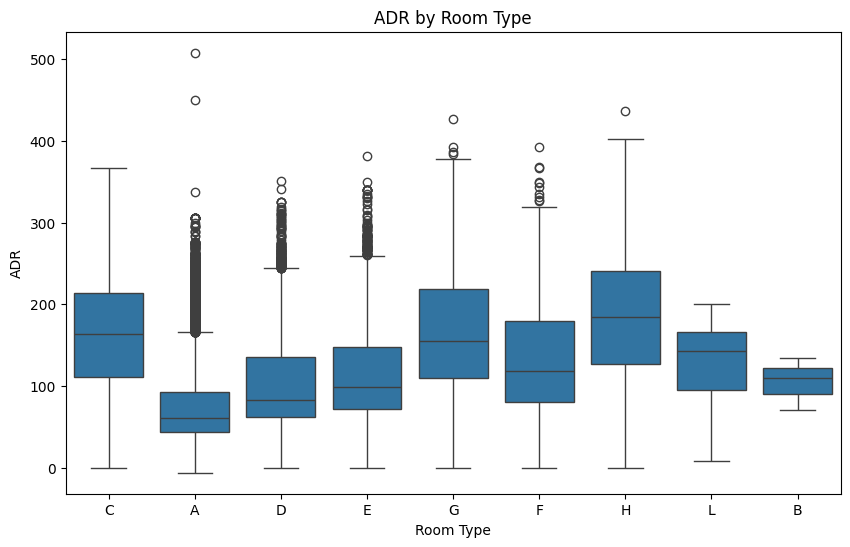

In [6]:
# boxplot for ADR by Room type Channel
plt.figure(figsize=(10, 6))
sns.boxplot(x='reserved_room_type', y='adr', data=Resort_hotel)
plt.title('ADR by Room Type')
plt.xlabel('Room Type')
plt.ylabel('ADR')
plt.show()

<Axes: xlabel='reserved_room_type'>

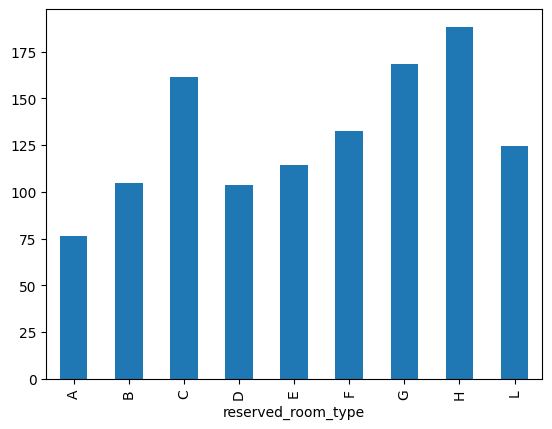

In [7]:
# ADR by room type

X = Resort_hotel.groupby('reserved_room_type')['adr'].mean()


X.plot(kind='bar')